In [1]:
suppressMessages({library(rwwa); library(quantreg); library(mev)})
png_res <- 240

# Quantile regression

In [5]:
gmst <- read.table("data/gmst.dat", col.names = c("year", "gmst"))
gmst$gmst <- gmst$gmst - gmst$gmst[gmst$year == 2026]

df <- merge(read.csv("data/tasmax_impact_daily_ts_ERA5-Land.csv"), read.csv("data/tasmin_impact_daily_ts_ERA5-Land.csv"))

df$year <- substr(df$time,1,4)
df$month <- substr(df$time,6,7)

df <- merge(gmst, df)
# df <- df[df$month %in% c(12,1,2),]

In [6]:
qq <- c(0.005,0.01,0.025,0.05,0.1,0.15,0.25,0.5,0.75,0.85,0.9,0.95,0.975,0.99,0.995)
qr_tmax <- rq(tasmax ~ gmst, data = df, tau = qq)
qpred_tmax <- fitted(qr_tmax) #  get fitted quantiles

qr_tmin <- rq(tasmin ~ gmst, data = df, tau = qq)
qpred_tmin <- fitted(qr_tmin) #  get fitted quantiles

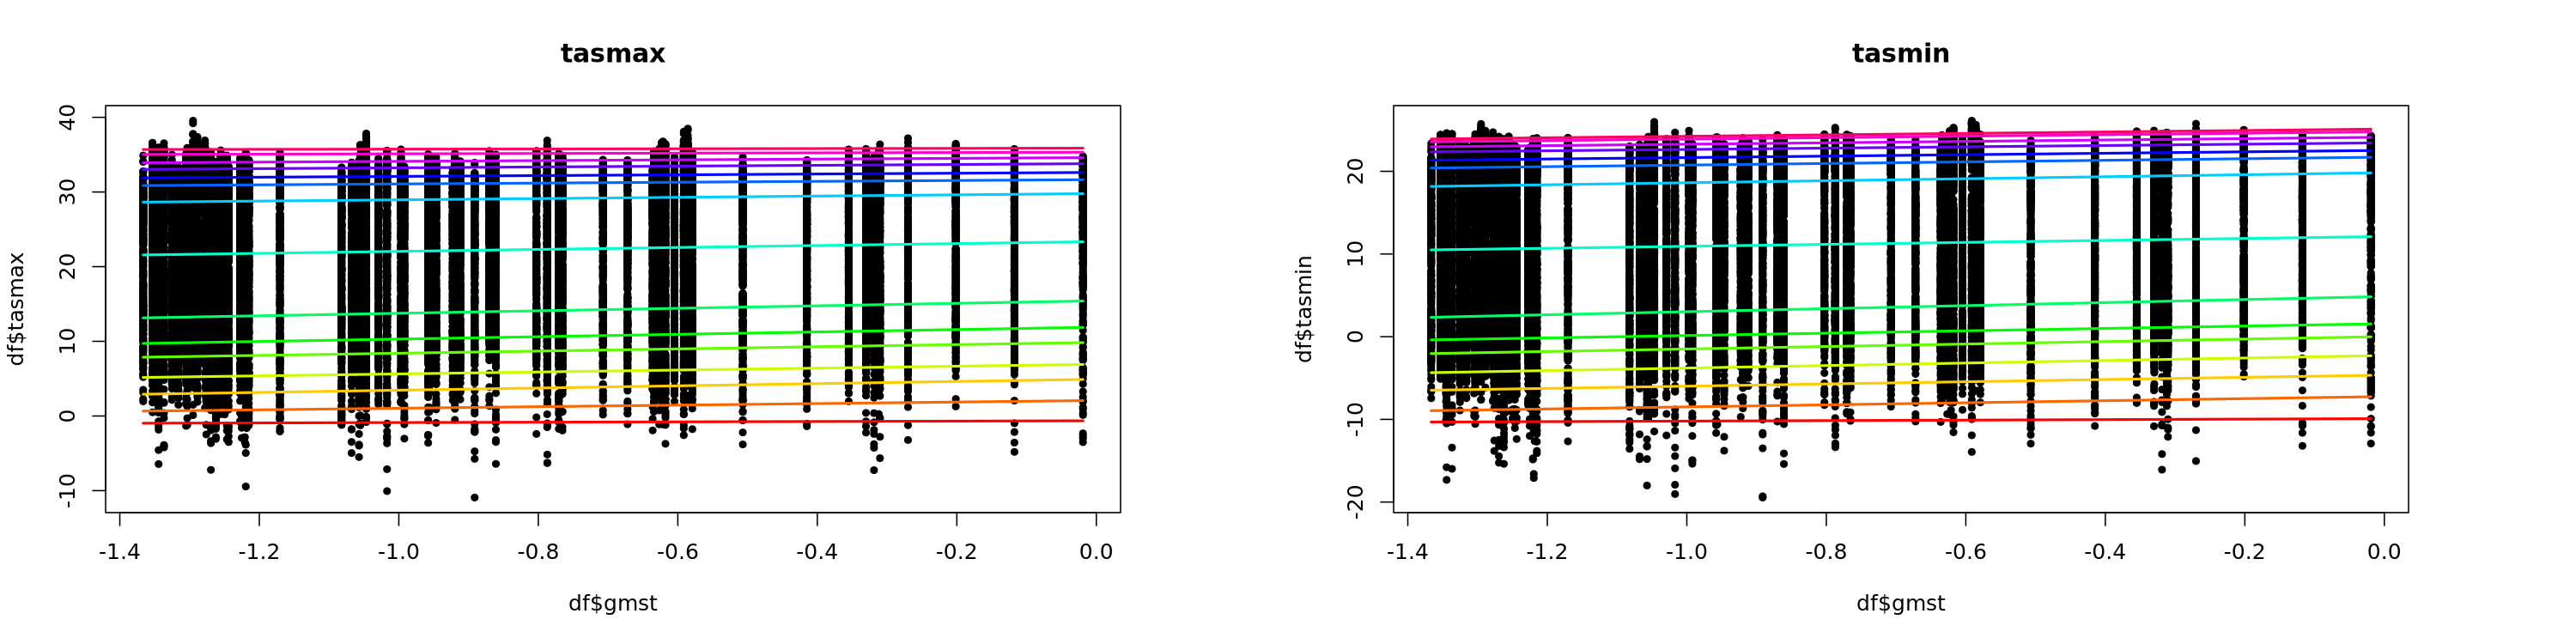

In [7]:
prep_window(c(1,2), xpd=TRUE, mar = c(5.1, 4.1, 4.1, 6.5), res = 150, h = 5, w = 10)
plot(df$gmst, df$tasmax, main = paste0("tasmax"))
matplot(df$gmst, qpred_tmax, add = T, type = "l", lty = 1, lwd = 2, col = rainbow(length(qq)))
# legend("right", inset = c(-0.22, 0), legend = qq, lty = 1, col = rainbow(length(qq)), bty = "n")

plot(df$gmst, df$tasmin, main = paste0("tasmin"))
matplot(df$gmst, qpred_tmin, add = T, type = "l", lty = 1, lwd = 2, col = rainbow(length(qq)))

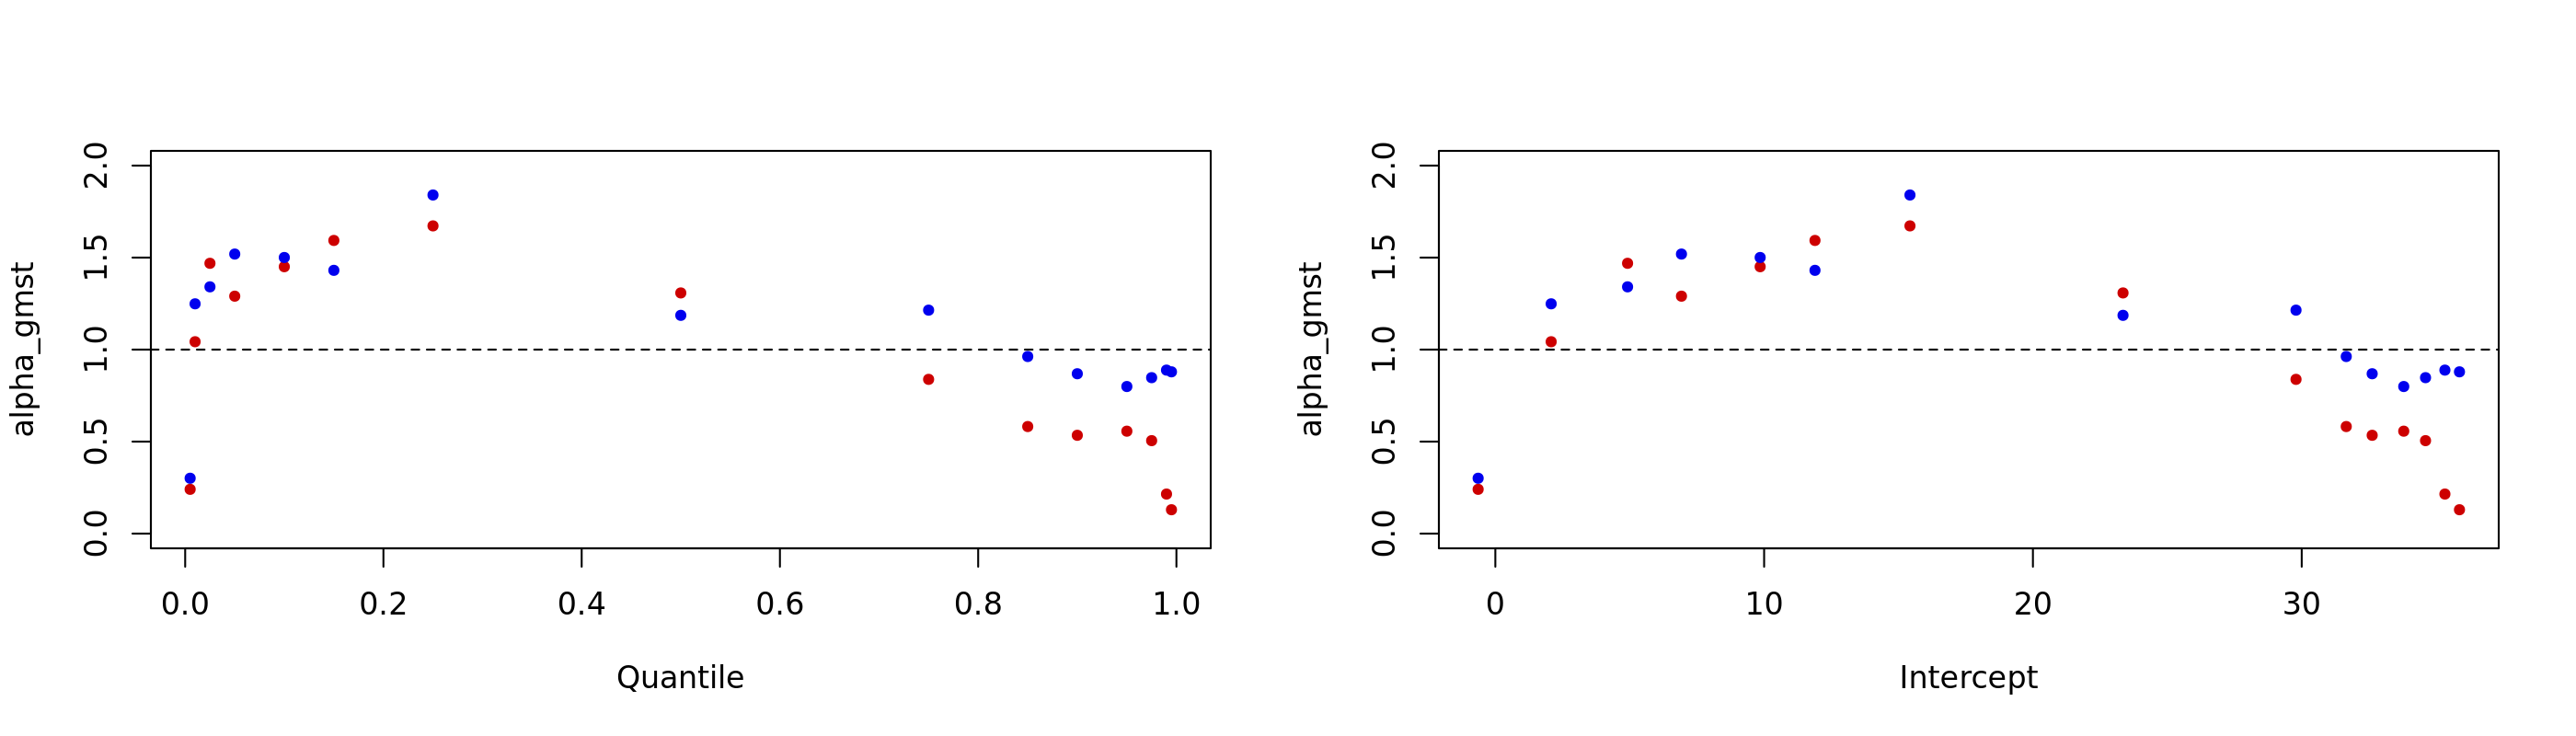

In [20]:
prep_window(c(1,2), w = 7)
matplot(qq, t(rbind("tmax" = coef(qr_tmax)["gmst",], "tmin" = coef(qr_tmin)["gmst",])), pch = 20, ylab = "alpha_gmst", col = c("red3", "blue2"), xlab = "Quantile", ylim = c(0,2))
abline(h = 1, lty = 2)

matplot(coef(qr_tmax)["(Intercept)",], t(rbind("tmax" = coef(qr_tmax)["gmst",], "tmin" = coef(qr_tmin)["gmst",])), pch = 20, ylab = "alpha_gmst", col = c("red3", "blue2"), xlab = "Intercept", ylim = c(0,2))
abline(h = 1, lty = 2)

# Joint change in temperature & precip

In [21]:
# rnm <- "impact"
# df <- merge(read.csv(paste0("data/pr_",rnm,"_daily_ts_ERA5-Land.csv")), read.csv(paste0("data/tasmax_",rnm,"_daily_ts_ERA5-Land.csv")))
# df$pr <- (df$pr + 273.15) * 86400

df <- read.csv("~/00_WWA_project_folder/ephemeral/us-snow/obs/ghcn-d_complete/stn_USW00094728.csv")
df$year <- as.integer(substr(df$date,1,4))
df$month <- as.integer(substr(df$date,6,7))

gmst <- read.table("data/gmst.dat", col.names = c("year", "gmst"))
gmst$gmst <- gmst$gmst - gmst$gmst[gmst$year == 2026]

df <- merge(gmst, df)
df <- df[df$month %in% c(12,1,2),]

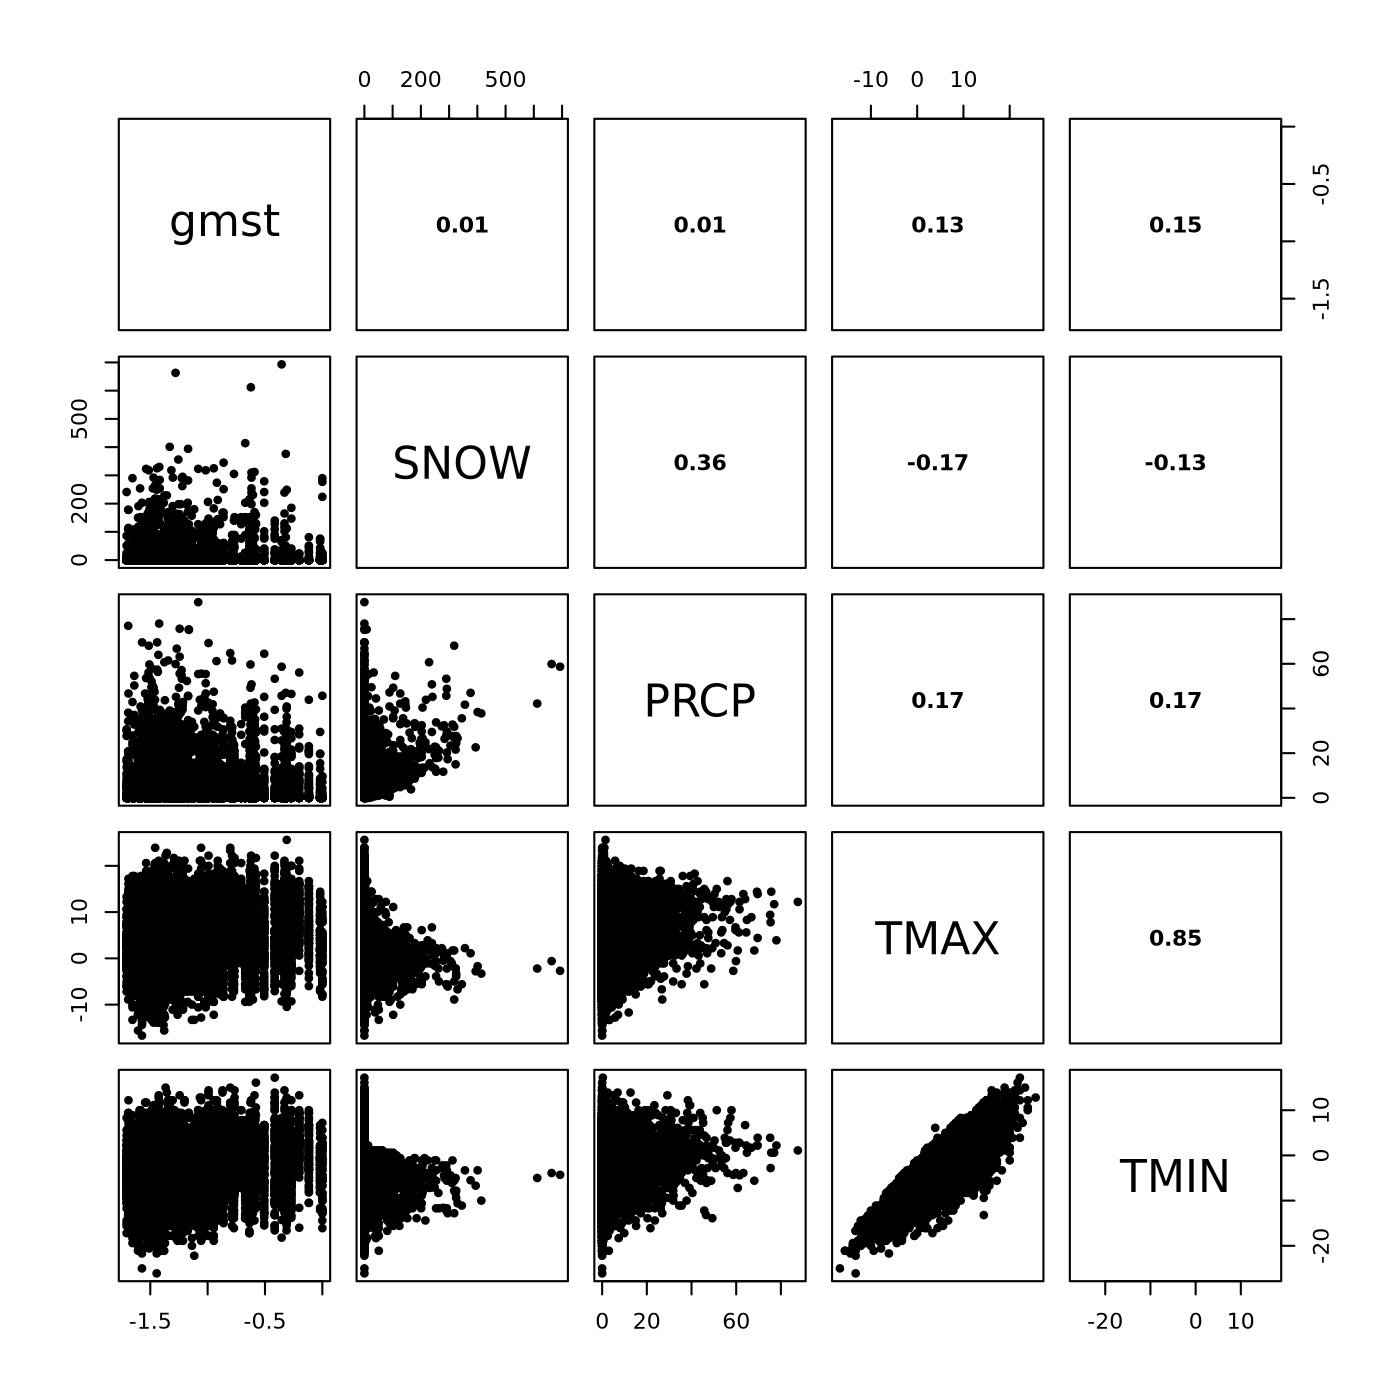

In [22]:
prep_window(h = 7, w = 7)
pairs(df[,c("gmst", "SNOW", "PRCP", "TMAX", "TMIN")], upper.panel = panel.cor)

## Marginal distributions

In [23]:
df$pr <- df$PRCP
df$tasmax <- df$TMAX
df <- df[!is.na(df$pr + df$tasmax),]

th <- 0
df <- df[df$pr > th,]

pr_segp = egp.fit(df$pr, model = "egp1", thresh = th) # extended GP estimate

In [24]:
# dextgp(x, type = 1, kappa = pr_segp$est["kappa"], sigma = pr_segp$est["scale"], xi = pr_segp$est["shape"])

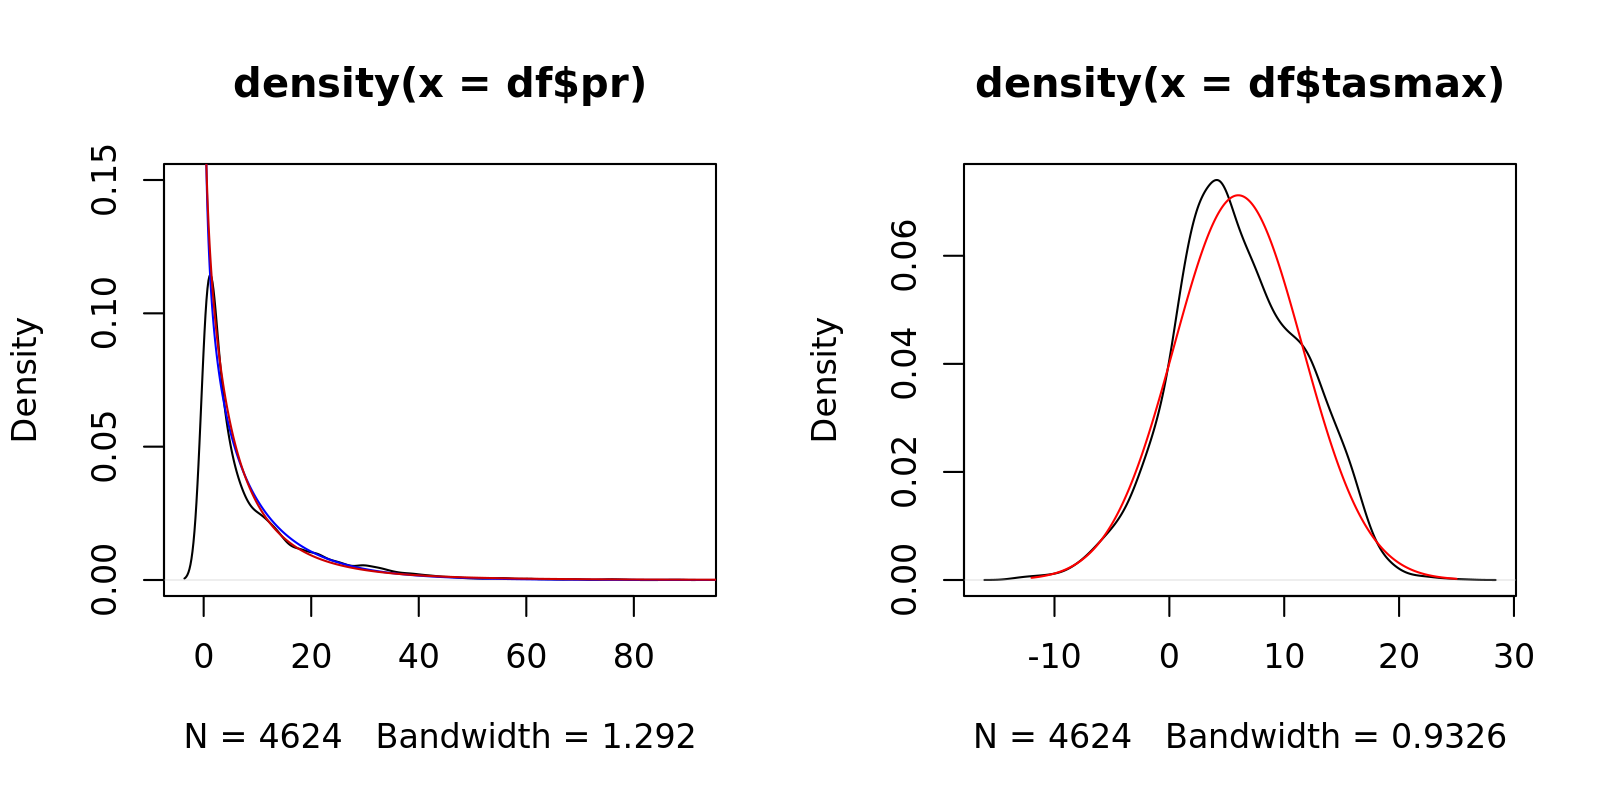

In [25]:
prep_window(c(1,2))

plot(density(df$pr), ylim = c(0,0.15))
par_gamma <- fitdistr(df$pr, "gamma")
lines(x <- seq(th,100, 0.1), dgamma(x, shape = par_gamma$estimate["shape"], rate = par_gamma$estimate["rate"]), col = "blue")
lines(x <- seq(th,100, 0.1), dextgp(x, type = 1, kappa = pr_segp$est["kappa"], sigma = pr_segp$est["scale"], xi = pr_segp$est["shape"]), col = "red3")

plot(density(df$tasmax))
lines(x <- seq(-12,25, 0.1), dnorm(x, mean(df$tasmax), sd(df$tasmax)), col = "red")

In [29]:
fwet <- df[df$PRCP > 0 & df$TMAX < 0,]

In [ ]:
plot(aggregate(rep(1, nrow(fwet)), by = list("year" = fwet$year), "sum"), pch = 20)

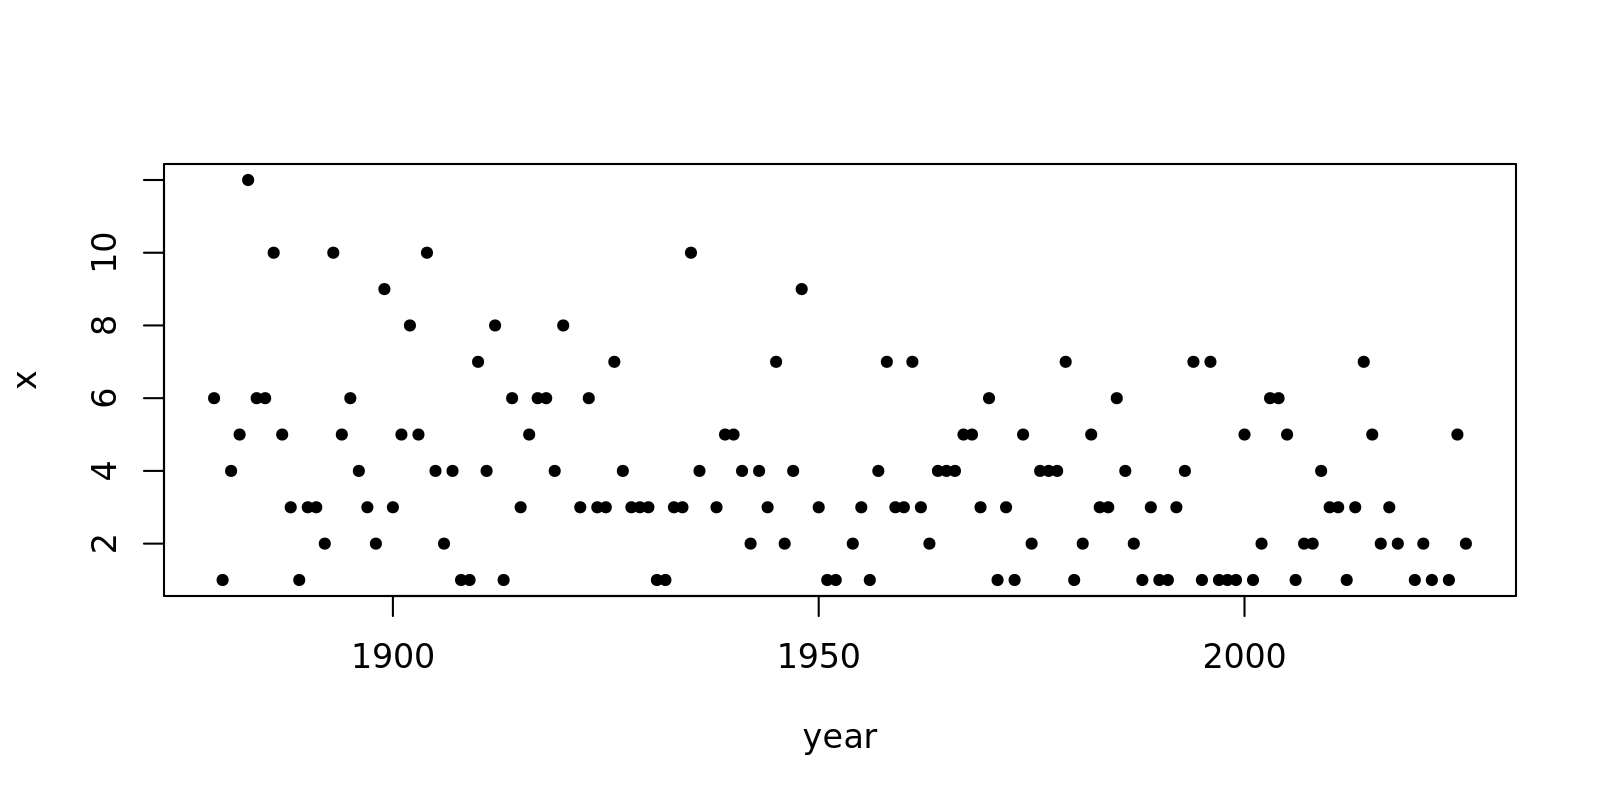

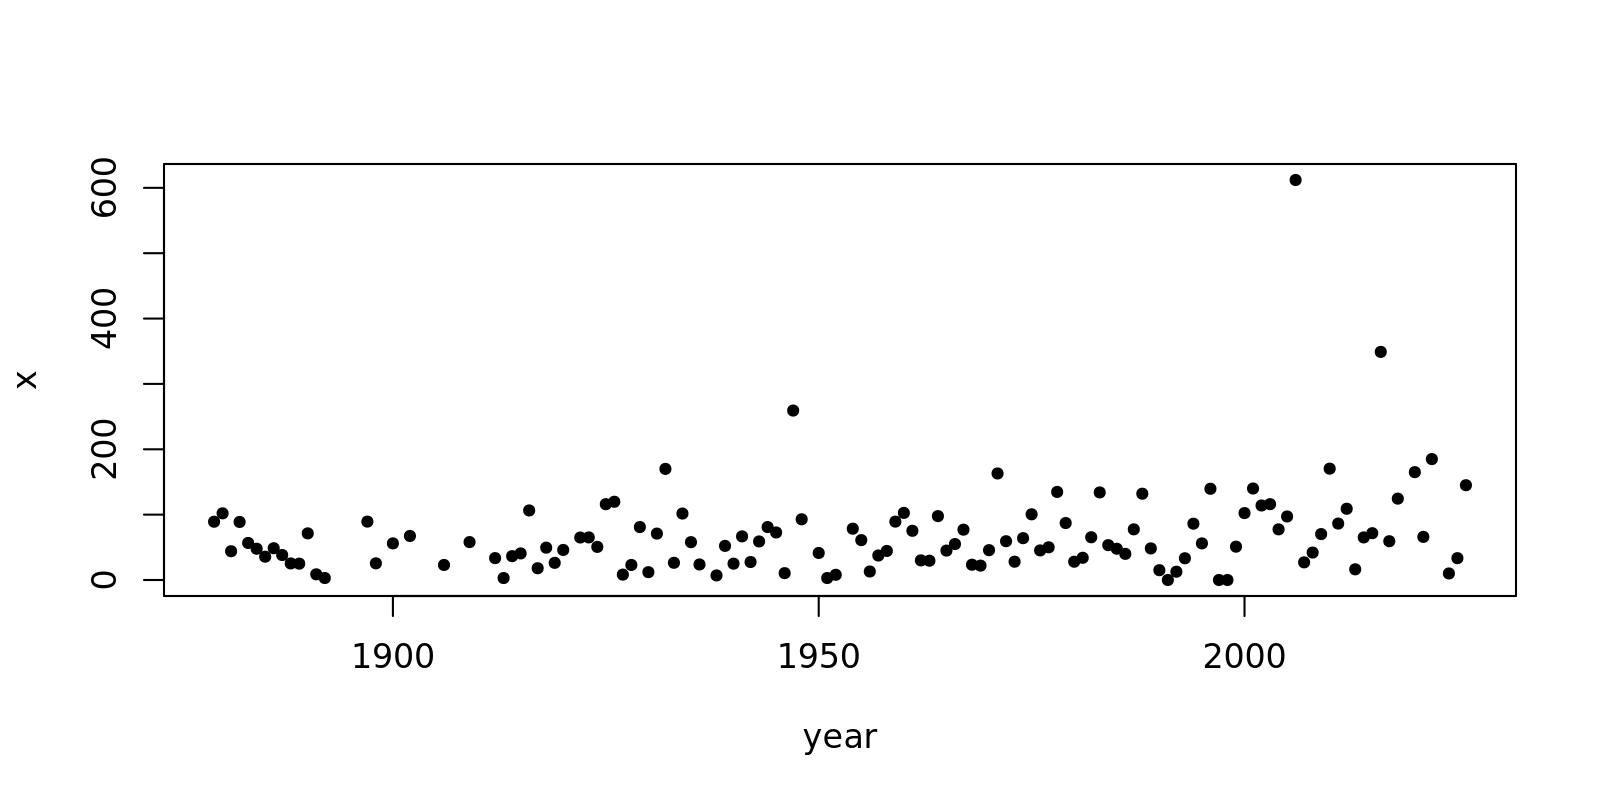

In [34]:
plot(aggregate(fwet$SNOW, by = list("year" = fwet$year), "mean"), pch = 20)

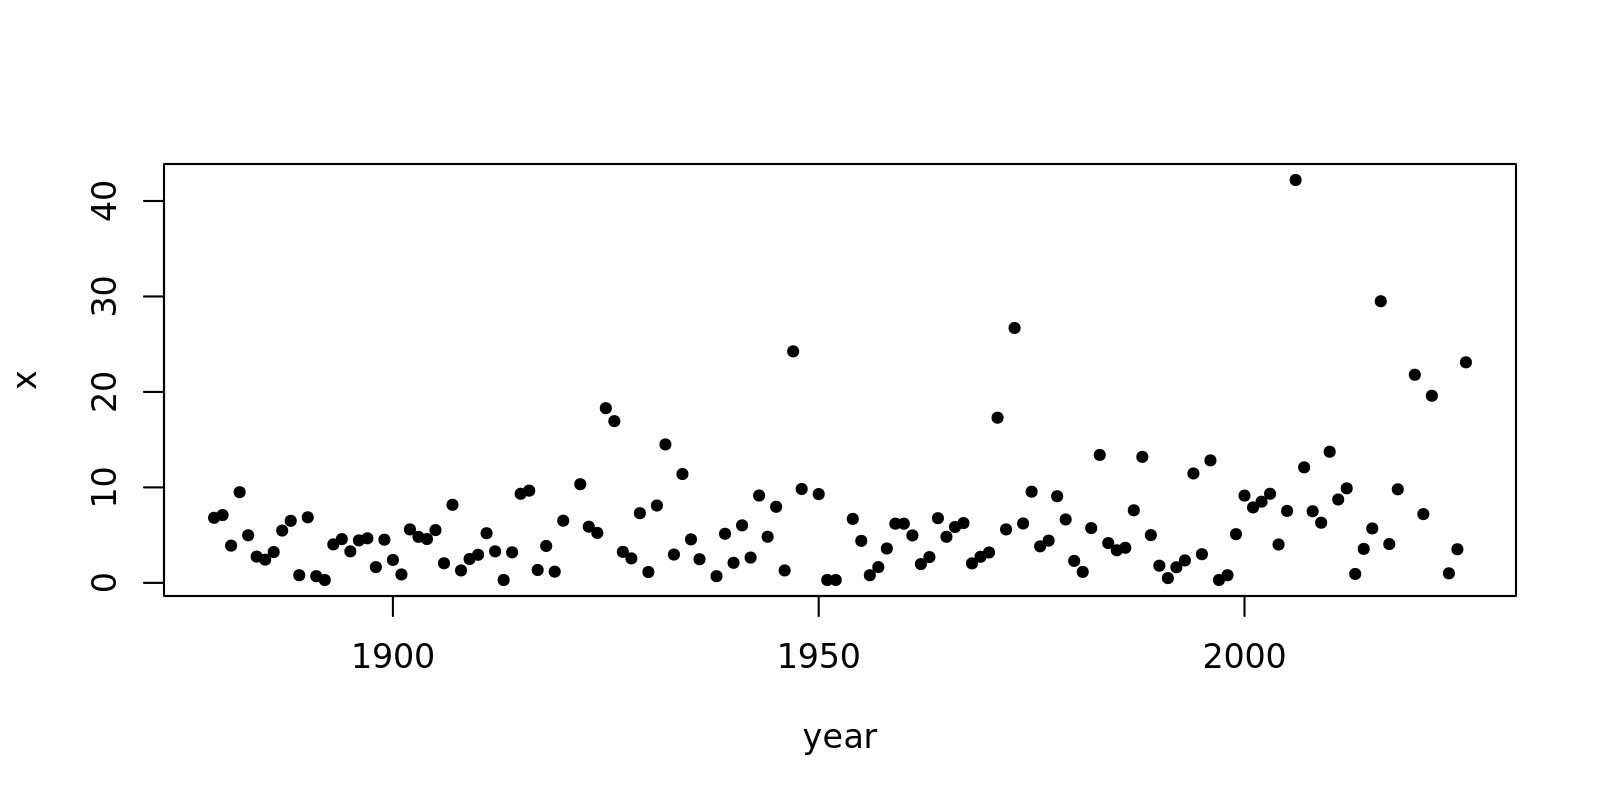

In [35]:
plot(aggregate(fwet$PRCP, by = list("year" = fwet$year), "mean"), pch = 20)

## Loop over stations, plot freezing wet days

In [156]:
fl <- list.files("~/00_WWA_project_folder/ephemeral/us-snow/obs/ghcn-d_complete", full.names = T)
png_res <- 360

gmst <- read.table("data/gmst.dat", col.names = c("year", "gmst"))
gmst$gmst <- gmst$gmst - gmst$gmst[gmst$year == 2026]

for (fnm in fl) {

    stn <- gsub(".+stn_|.csv","",fnm)
    # load data, filter to just the winter months
    df <- read.csv(fnm)
    df$year <- as.integer(substr(df$date,1,4))
    df$month <- as.integer(substr(df$date,6,7))
    df <- df[df$month %in% c(12,1,2),]

    fwet <- df[df$PRCP > 0 & df$TMAX < 0,]
    fwet <- Reduce(function(df1, df2) merge(df1, df2, by = "year"),
        list(aggregate(rep(1, nrow(fwet)), by = list("year" = fwet$year), "sum"),
             aggregate(fwet$SNOW, by = list("year" = fwet$year), "mean"),
             aggregate(fwet$PRCP, by = list("year" = fwet$year), "mean")))
    colnames(fwet) <- c("year", "nfwet", "snow", "prcp")
    fwet <- merge(fwet, gmst)

    # fit a speedy linear model through the numbers (for visualisation only)
    mdl <- lm(cbind(nfwet, snow, prcp) ~ gmst, data = fwet)
    fit <- fitted(mdl)

    png(paste0("fig/fwetdays_stn-",stn,".png"), h = png_res*.8, w = png_res * 3); {
        prep_window(c(1,3), oma = c(0,0,2,0))
        plot(fwet$year, fwet$nfwet, pch = 20, ylab = "Freezing / wet days", xlab = "", 
             main = paste0("Number of wet days with freezing temps,\n alpha = ", round(coef(mdl)["gmst","nfwet"], 3)))
        lines(fwet$year, fitted(loess(nfwet ~ year, fwet)), col = "forestgreen", lwd = 2, lty = "22")
        lines(fwet[rownames(fit),]$year, fit[,"nfwet"], col = "red3", lwd = 2, lty = "22")
    
        plot(fwet$year, fwet$snow, pch = 20, ylab = "Snowfall (mm)", xlab = "",
             main = paste0("Mean snowfall on freezing wet days,\n alpha = ", round(coef(mdl)["gmst","snow"], 3)))
        lines(fwet$year[!is.na(fwet$snow)], fitted(loess(snow ~ year, fwet)), col = "forestgreen", lwd = 2, lty = "22")
        lines(fwet[rownames(fit),]$year, fit[,"snow"], col = "red3", lwd = 2, lty = "22")
    
        plot(fwet$year, fwet$prcp, pch = 20, ylab = "Precipitation (mm)", xlab = "", 
             main = paste0("Mean precipitation on freezing wet days,\n alpha = ", round(coef(mdl)["gmst","prcp"], 3)))
        lines(fwet$year, fitted(loess(prcp ~ year, fwet)), col = "forestgreen", lwd = 2, lty = "22")
        lines(fwet[rownames(fit),]$year, fit[,"prcp"], col = "red3", lwd = 2, lty = "22")
    
        mtext(paste0(stn, " - ", md[stn,"name"]) , side = 3, outer = T, font = 2)
    }; dev.off()
}

In [191]:
alpha <- t(sapply(fl, function(fnm) {
    stn <- gsub(".+stn_|.csv","",fnm)
    df <- read.csv(fnm)
    df$year <- as.integer(substr(df$date,1,4))
    df$month <- as.integer(substr(df$date,6,7))
    df <- df[df$month %in% c(12,1,2),]

    fwet <- df[df$PRCP > 0 & df$TMAX < 0,]
    fwet <- Reduce(function(df1, df2) merge(df1, df2, by = "year"),
        list(aggregate(rep(1, nrow(fwet)), by = list("year" = fwet$year), "sum"),
             aggregate(fwet$SNOW, by = list("year" = fwet$year), "mean"),
             aggregate(fwet$PRCP, by = list("year" = fwet$year), "mean")))
    colnames(fwet) <- c("year", "nfwet", "snow", "prcp")
    fwet <- merge(fwet, gmst)

    # fit a speedy linear model through the numbers (for visualisation only)
    mdl <- lm(cbind(nfwet, snow, prcp) ~ gmst, data = fwet)
    coef(mdl)["gmst",,drop = F]
    
}, simplify = T))
rownames(alpha) <- gsub(".+stn_|.csv","",fl)
colnames(alpha) <- colnames(fwet)[2:4]

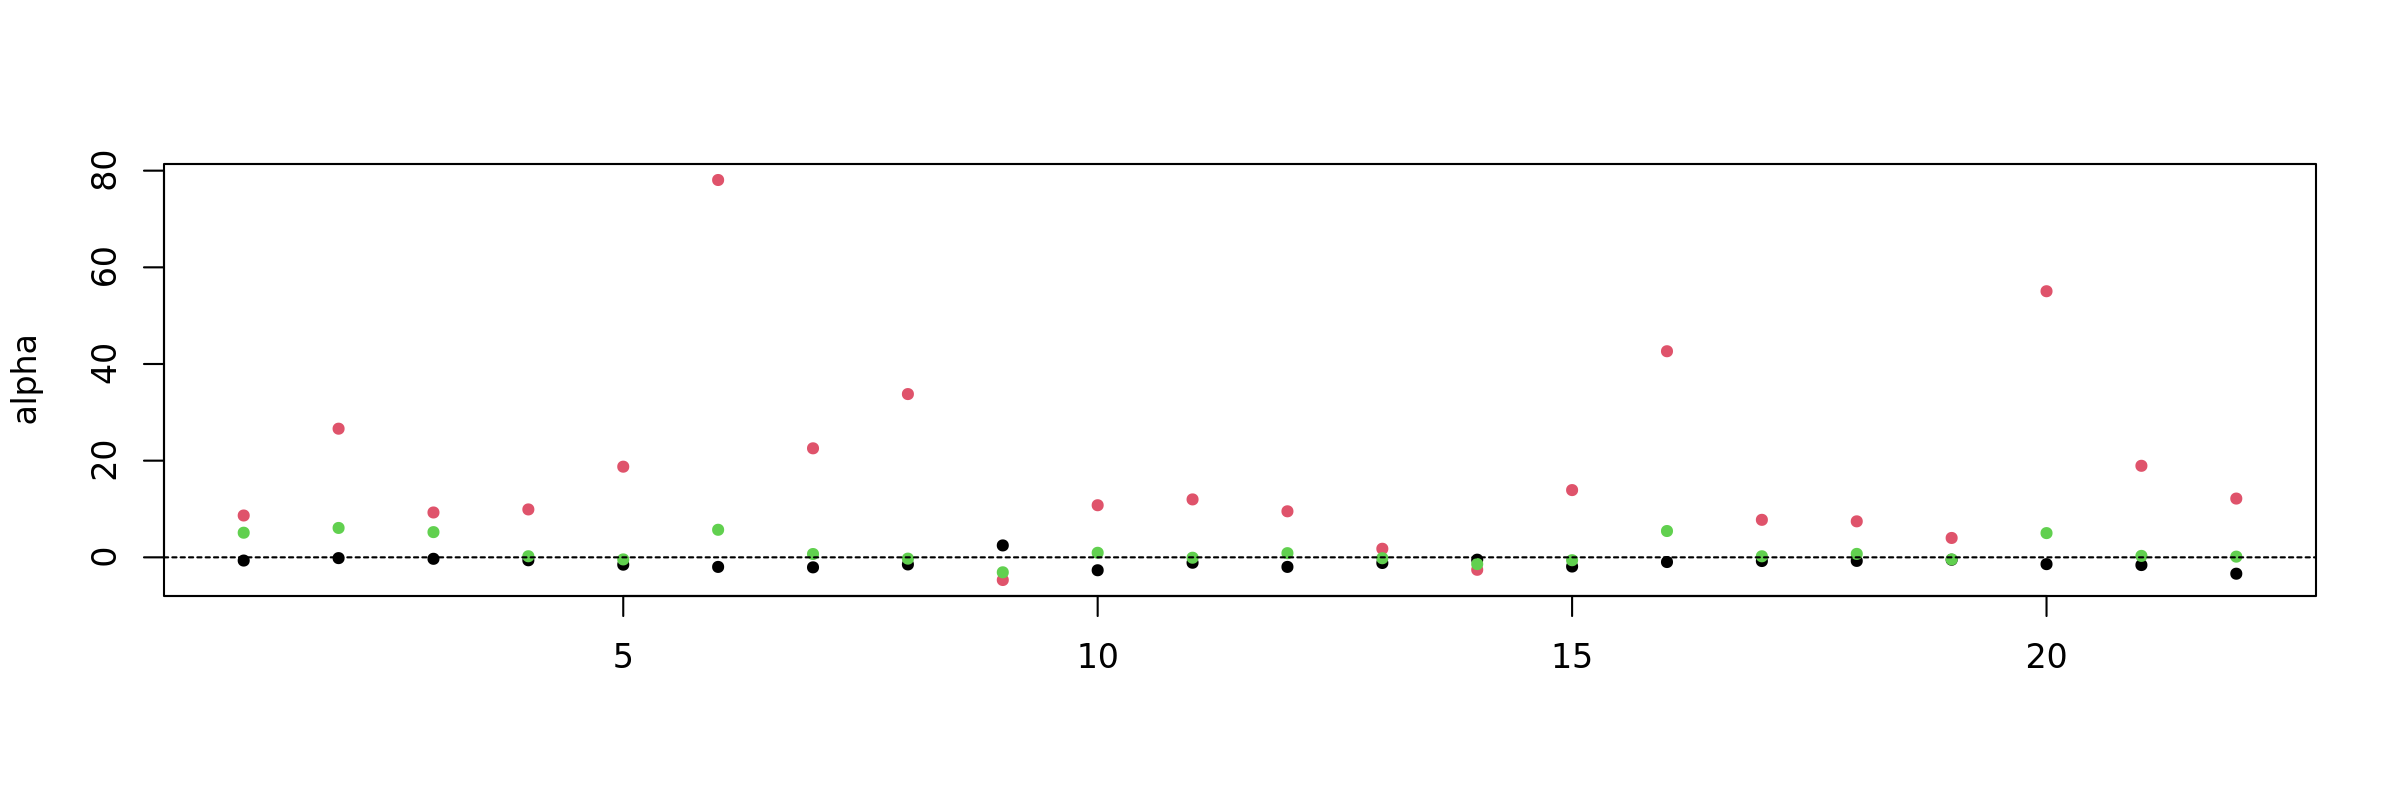

In [186]:
matplot(alpha, pch = 20)
abline(h = 0, lty = "22")

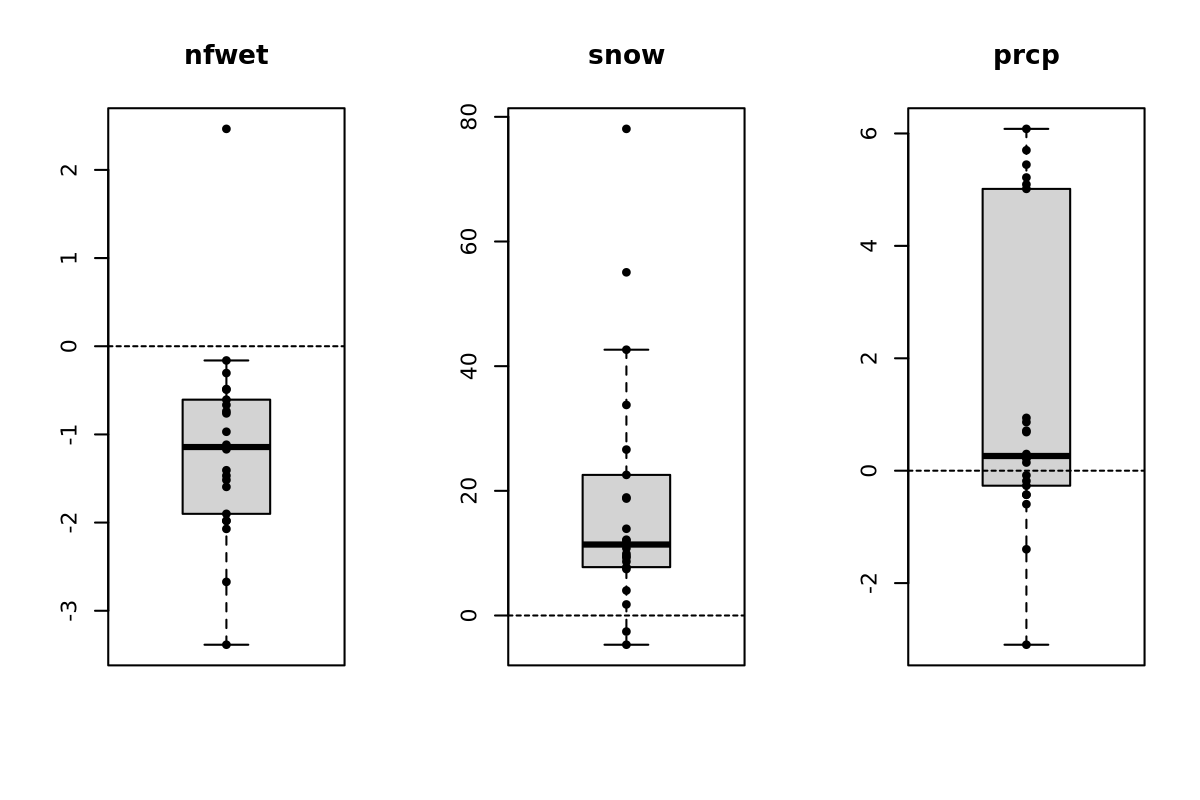

In [205]:
prep_window(c(1,3), w = 2)
for (i in 1:3) {
    boxplot(alpha[,i], main = colnames(alpha)[i])
    points(rep(1,22), alpha[,i])
    abline(h = 0, lty = "22")
}

In [208]:
alpha[order(alpha[,3]),]

,nfwet,snow,prcp
USW00014755,2.4653329,-4.688629,-3.09626332
USW00023042,-0.4851410,-2.576726,-1.39797287
USW00023047,-1.9007640,13.914994,-0.59534005
USW00013967,-1.5169274,18.756435,-0.42811504
USW00093822,-0.4926726,4.009566,-0.42731522
USW00014739,-1.4680064,33.779477,-0.26702869
USW00014821,-1.1691655,1.774699,-0.18249046
USW00014768,-1.1169911,11.984982,-0.08172196
USW00094823,-3.3852829,12.159288,0.14505976
USW00093814,-0.7616467,7.758446,0.22009136


In [203]:
which.min(alpha[,"snow"])

USW00014755 
          9